<img src="./figs/IOAI-Logo.png" alt="IOAI Logo" width="200" height="auto">

[IOAI 2025 (Beijing, China), At-Home Round](https://ioai-official.org/china-2025)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IOAI-official/IOAI-2025/blob/main/At-Home-Round/Chameleon/Chameleon_Solution.ipynb)

## Data Loading

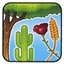

Flora
Plant
Nature


In [35]:
from IPython.display import display
from PIL import Image
from datasets import Dataset
TRAIN_TEXT = "/bohr/train-7ul9/v2"
hint_description = Dataset.load_from_disk(TRAIN_TEXT + "/dataset/hint_descriptions")
hint_description = {
    x['ID']: {'description': x['Description'], 'icons': x['image']}
    for x in hint_description
}

# show example
display(hint_description[7]['icons'])
print(hint_description[7]['description'])

In [36]:
from torch.utils.data import random_split
import torch
# Assuming validation_data is a PyTorch Dataset object
validation_data = Dataset.load_from_disk(TRAIN_TEXT + "/dataset/takehome_validation")
dataset_size = len(validation_data)
validation_size = int(dataset_size * 0.5)
train_size = dataset_size - validation_size
train_data, validation_data = random_split(validation_data, [train_size, validation_size])
print(len(validation_data))

10


## Implement keyword guesser

Internet access is allowed in Bohrium, so contestants could download pre-trained models from huggingface. However, since the servers are hosted on mainland China, they are subject to internet restrictions that blocks access to sources like huggingface. To circumvent this, we can use hosted mirror servers(which we'll also provide at the on-site round). For huggingface, you can set os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'  to use a huggingface mirror that's accessible from Bohrium's server.

In [37]:
import os
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'

In [40]:
import logging
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Set up logging to display download progress
logging.basicConfig(level=logging.INFO)

# Load the model
model = SentenceTransformer('sentence-t5-base')

# Encode some sentences
embeddings = model.encode([
    'hello world',
    'fun and games'
])

print(f"Embedding shape: {embeddings.shape}")

INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cuda:0
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: sentence-t5-base


In [ ]:
def hints_to_sentence(hints: list[int]) -> str:
  sentence = "The following hints at our target word:\n<HINT_PRIMARY>\n"
  for i, hint in enumerate(hints):
    sentence += f"{hint_description[hint]['description']}"
    if i == 0:
      sentence += "\n</HINT_PRIMARY>\n<HINT>\n"
    elif i < len(hints) - 1:
      sentence += "\n</HINT>\n<HINT>\n"
    else:
      sentence += "\n</HINT>"
  return sentence

def choice_to_doc(choice:str)->str:
  return f"{choice}"

print(hints_to_sentence([1, 2, 3]))

In [ ]:
# Fine-tune the model

from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
from torch.utils.data import DataLoader

import os
os.environ["WANDB_DISABLED"] = "true"

train_examples = []

for val in validation_data:
  train_examples.append(InputExample(texts=[hints_to_sentence(val['hints']), choice_to_doc(val['label'])], label=1))
# Create DataLoader
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=2)

# Define loss function
train_loss = losses.CosineSimilarityLoss(model)

model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=80,
    warmup_steps=5,
    output_path='./model',
    optimizer_params={'lr': 1e-6},
    weight_decay=0.01,
    save_best_model=True,
    show_progress_bar=True
)

In [ ]:
ft_model_loaded = SentenceTransformer("./model") # Load fine-tuned model

def find_most_similar(query, sentences, model, top_k=10):
    # Encode query and sentences
    query_embedding = model.encode([query])
    sentence_embeddings = model.encode(sentences)

    # Calculate similarities
    similarities = cosine_similarity(query_embedding, sentence_embeddings)[0]

    # Get top-k most similar
    top_indices = np.argsort(similarities)[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            'sentence': sentences[idx],
            'similarity': similarities[idx]
        })

    return results

def guess_words(hints: list[int], choices: list[str]) -> list[str]:
    query = hints_to_sentence(hints)
    results = find_most_similar(query, choices, ft_model_loaded)
    return [result['sentence'] for result in results]

In [ ]:
import math

def score(guesses: list[str], gold: str):
    # Normalize to lowercase
    guesses = [g.lower() for g in guesses[:10]]
    gold = gold.lower()

    result = {
        "hits@10": 0.0,
        "ndcg@10": 0.0,
        "total_score": 0.0
    }

    if gold in guesses:
        rank = guesses.index(gold)
        result["hits@10"] = 1.0
        result["ndcg@10"] = 1.0 / math.log2(rank + 2)  # rank + 2 because index is 0-based
    else:
        result["hits@10"] = 0.0
        result["ndcg@10"] = 0.0

    result["total_score"] = 0.9 * result["hits@10"] + 0.1 * result["ndcg@10"]
    return result

print(score(['cat', 'dog', 'tree', 'flower', 'rock', 'water', 'fried rice', 'airplane', 'cactus', 'tiger'], gold='cactus'))

In [ ]:
from tqdm.notebook import tqdm

# score on validation set
guesses = []
total_scores = 0.0
for example in tqdm(validation_data):
    guesses.append(guess_words(example['hints'], example['options']))
    total_scores += score(guesses[-1], example['label'])['total_score']
print(f"Average train score: {total_scores / len(validation_data)}")
guesses = []
total_scores = 0.0
for example in tqdm(train_data):
    guesses.append(guess_words(example['hints'], example['options']))
    total_scores += score(guesses[-1], example['label'])['total_score']
print(f"Average validation score: {total_scores / len(train_data)}")

## Model Submission

In [ ]:
model_code = """
from sentence_transformers import SentenceTransformer
from datasets import Dataset
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

TRAIN_TEXT = "/bohr/train-7ul9/v2"
hint_description = Dataset.load_from_disk(TRAIN_TEXT + "/dataset/hint_descriptions")
hint_description = {
    x['ID']: {'description': x['Description'], 'icons': x['image']}
    for x in hint_description
}

model = SentenceTransformer("./model")

def hints_to_sentence(hints: list[int]) -> str:
  sentence = "The following hints at our target word:\\n<HINT_PRIMARY>\\n"
  for i, hint in enumerate(hints):
    sentence += f"{hint_description[hint]['description']}"
    if i == 0:
      sentence += "\\n</HINT_PRIMARY>\\n<HINT>\\n"
    elif i < len(hints) - 1:
      sentence += "\\n</HINT>\\n<HINT>\\n"
    else:
      sentence += "\\n</HINT>"
  return sentence

def choice_to_doc(choice:str)->str:
  return f"Our target word: {choice}"

def find_most_similar(query, sentences, model, top_k=10):
    # Encode query and sentences
    query_embedding = model.encode([query])
    sentence_embeddings = model.encode(sentences)

    # Calculate similarities
    similarities = cosine_similarity(query_embedding, sentence_embeddings)[0]

    # Get top-k most similar
    top_indices = np.argsort(similarities)[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            'sentence': sentences[idx],
            'similarity': similarities[idx]
        })

    return results

def guess_words(hints: list[int], choices: list[str]) -> list[str]:
  query = hints_to_sentence(hints)
  results = find_most_similar(query, choices, model)
  return [result['sentence'] for result in results]
"""

with open("submission_model.py", "w") as f:
  f.write(model_code)

print("Inference code written to submission_model.py")

In [ ]:
import shutil
import os
import tempfile

# Create a temporary directory with your desired structure
with tempfile.TemporaryDirectory() as temp_dir:
    # Copy files to temp directory
    shutil.copy('submission_model.py', temp_dir)
    shutil.copytree('./model', os.path.join(temp_dir, 'model'))
    
    # Create the zip
    shutil.make_archive('submission', 'zip', temp_dir)